<a href="https://colab.research.google.com/github/Kazureee/Inventory-Management/blob/main/Final%20Project/Cash%20Flow%20versus%20Profitability%20in%20Bankruptcy%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cash Flow versus Profitability in Bankruptcy Detection

Goal: To analyze whether cash flow indicators are more effective than profitability indicators in distinguishing between bankrupt and non-bankrupt companies.

In [ ]:
# Load the data
import pandas as pd
df = pd.read_csv('data.csv')

print("Dataset loaded")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

Dataset loaded
Rows: 6819
Columns: 96


In [ ]:
# Look at actual data
print("First 3 rows of data:")
print(df.head(3).T.head(15))

First 3 rows of data:
                                                           0         1  \
Bankrupt?                                           1.000000  1.000000   
 ROA(C) before interest and depreciation before...  0.370594  0.464291   
 ROA(A) before interest and % after tax             0.424389  0.538214   
 ROA(B) before interest and depreciation after tax  0.405750  0.516730   
 Operating Gross Margin                             0.601457  0.610235   
 Realized Sales Gross Margin                        0.601457  0.610235   
 Operating Profit Rate                              0.998969  0.998946   
 Pre-tax net Interest Rate                          0.796887  0.797380   
 After-tax net Interest Rate                        0.808809  0.809301   
 Non-industry income and expenditure/revenue        0.302646  0.303556   
 Continuous interest rate (after tax)               0.780985  0.781506   
 Operating Expense Rate                             0.000126  0.000290   
 Research and de

In [ ]:
# Check actual values, not just unique()
print("Checking 'Bankrupt?' column values:")

# Get value counts
value_counts = df['Bankrupt?'].value_counts()
print("\nValue distribution:")
print(value_counts)

# Check first 10 actual values
print("\nFirst 10 values:")
print(df['Bankrupt?'].head(10).values)

# Are they all 1.0? Let's check
unique_vals = df['Bankrupt?'].unique()
print(f"\nUnique values: {unique_vals}")
print(f"Number of unique values: {len(unique_vals)}")

# Look at data types
print(f"\nData type: {df['Bankrupt?'].dtype}")

Checking 'Bankrupt?' column values:

Value distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

First 10 values:
[1 1 1 1 1 1 0 0 0 0]

Unique values: [1 0]
Number of unique values: 2

Data type: int64


# Analyzing which financial ratios best separate bankrupt vs healthy companies

In [ ]:
import numpy as np

print("Now analyzing which financial ratios best separate bankrupt vs healthy companies...")
print("="*70)

# Separate groups
group1 = df[df['Bankrupt?'] == 1]  # Bankrupt
group0 = df[df['Bankrupt?'] == 0]  # Healthy

print(f"Group sizes: Bankrupt={len(group1):,}, Healthy={len(group0):,}")

# Function to measure separation power
def separation_power(var_name):
    mean1 = group1[var_name].mean()
    mean0 = group0[var_name].mean()
    std1 = group1[var_name].std()
    std0 = group0[var_name].std()
    n1 = len(group1)
    n0 = len(group0)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n0-1)*std0**2) / (n1 + n0 - 2))

    if pooled_std == 0:
        return 0

    # Effect size (Cohen's d)
    return abs(mean0 - mean1) / pooled_std

print("\nCalculating separation power for all financial ratios...")
print("(Higher number = better at distinguishing bankrupt from healthy)")
print("-"*70)

# Calculate for all variables except target
strength_results = []
for col in df.columns:
    if col != 'Bankrupt?':
        strength = separation_power(col)
        strength_results.append((strength, col))

# Sort by strength (highest first)
strength_results.sort(reverse=True)

print("\nTop 10 financial ratios with highest separation power:")
print("-"*70)
for i, (strength, var) in enumerate(strength_results[:10], 1):
    print(f"{i:2d}. Strength: {strength:.3f} | Variable: {var}")

Now analyzing which financial ratios best separate bankrupt vs healthy companies...
Group sizes: Bankrupt=220, Healthy=6,599

Calculating separation power for all financial ratios...
(Higher number = better at distinguishing bankrupt from healthy)
----------------------------------------------------------------------

Top 10 financial ratios with highest separation power:
----------------------------------------------------------------------
 1. Strength: 1.881 | Variable:  Net Income to Total Assets
 2. Strength: 1.669 | Variable:  ROA(A) before interest and % after tax
 3. Strength: 1.606 | Variable:  ROA(B) before interest and depreciation after tax
 4. Strength: 1.529 | Variable:  ROA(C) before interest and depreciation before interest
 5. Strength: 1.462 | Variable:  Net worth/Assets
 6. Strength: 1.462 | Variable:  Debt ratio %
 7. Strength: 1.273 | Variable:  Persistent EPS in the Last Four Seasons
 8. Strength: 1.263 | Variable:  Retained Earnings to Total Assets
 9. Strength: 

In [ ]:
print("Categorizing variables to compare Cash Flow vs Profitability...")
print("="*70)

# Define categories based on variable names
cash_flow_keywords = ['cash', 'flow', 'cfo']
profitability_keywords = ['roa', 'profit', 'income', 'margin', 'eps', 'earning', 'return']

categorized_results = []
for strength, var in strength_results:
    var_lower = var.lower()

    if any(keyword in var_lower for keyword in cash_flow_keywords):
        category = 'Cash Flow'
    elif any(keyword in var_lower for keyword in profitability_keywords):
        category = 'Profitability'
    else:
        category = 'Other'

    categorized_results.append((strength, var, category))

# Count by category
category_counts = {}
category_strengths = {'Cash Flow': [], 'Profitability': [], 'Other': []}

for strength, var, category in categorized_results:
    category_counts[category] = category_counts.get(category, 0) + 1
    category_strengths[category].append(strength)

print("\nCategory Summary:")
print("-"*40)
for category, count in category_counts.items():
    avg_strength = np.mean(category_strengths[category])
    max_strength = np.max(category_strengths[category])
    print(f"{category:15} | Variables: {count:3d} | Avg strength: {avg_strength:.3f} | Max: {max_strength:.3f}")

print("\nTop 5 from each category:")
print("-"*40)

# Show top from each category
for category in ['Profitability', 'Cash Flow']:
    if category in category_counts:
        print(f"\n{category}:")
        cat_vars = [(s, v) for s, v, c in categorized_results if c == category]
        cat_vars.sort(reverse=True)
        for i, (strength, var) in enumerate(cat_vars[:5], 1):
            print(f"  {i}. {strength:.3f} | {var}")

Categorizing variables to compare Cash Flow vs Profitability...

Category Summary:
----------------------------------------
Profitability   | Variables:  25 | Avg strength: 0.691 | Max: 1.881
Other           | Variables:  59 | Avg strength: 0.388 | Max: 1.462
Cash Flow       | Variables:  11 | Avg strength: 0.354 | Max: 0.657

Top 5 from each category:
----------------------------------------

Profitability:
  1. 1.881 |  Net Income to Total Assets
  2. 1.669 |  ROA(A) before interest and % after tax
  3. 1.606 |  ROA(B) before interest and depreciation after tax
  4. 1.529 |  ROA(C) before interest and depreciation before interest
  5. 1.273 |  Persistent EPS in the Last Four Seasons

Cash Flow:
  1. 0.657 |  CFO to Assets
  2. 0.569 |  Cash/Total Assets
  3. 0.442 |  Cash/Current Liability
  4. 0.440 |  Cash Flow Per Share
  5. 0.411 |  Cash flow rate


In [ ]:
# Calculate comparison metrics
profit_avg = np.mean([s for s, _, c in categorized_results if c == 'Profitability'])
cash_avg = np.mean([s for s, _, c in categorized_results if c == 'Cash Flow'])

profit_max = max([s for s, _, c in categorized_results if c == 'Profitability'])
cash_max = max([s for s, _, c in categorized_results if c == 'Cash Flow'])

print(f"1. Profitability average strength: {profit_avg:.3f}")
print(f"2. Cash flow average strength:     {cash_avg:.3f}")
print(f"3. Profitability is {profit_avg/cash_avg:.1f}x stronger on average")
print(f"4. Best profitability: {profit_max:.3f}")
print(f"5. Best cash flow:     {cash_max:.3f}")
print(f"6. Profitability is {profit_max/cash_max:.1f}x stronger at best")

1. Profitability average strength: 0.691
2. Cash flow average strength:     0.354
3. Profitability is 2.0x stronger on average
4. Best profitability: 1.881
5. Best cash flow:     0.657
6. Profitability is 2.9x stronger at best


# FINAL ANALYSIS

**RESEARCH QUESTION:**
Are cash flow indicators more effective than profitability
indicators for distinguishing bankrupt vs healthy companies?

---

**DATA-DRIVEN ANSWER:**
NO

---

EVIDENCE:
1. Profitability average strength: 0.691
2. Cash flow average strength:     0.354
3. Profitability is 2.0x stronger on average

4. Best profitability: 1.881
5. Best cash flow:     0.657
6. Profitability is 2.9x stronger at best

---

**CONCLUSION:**
Profitability indicators are more effective than cash flow indicators for bankruptcy detection.

---



# Data Visualization

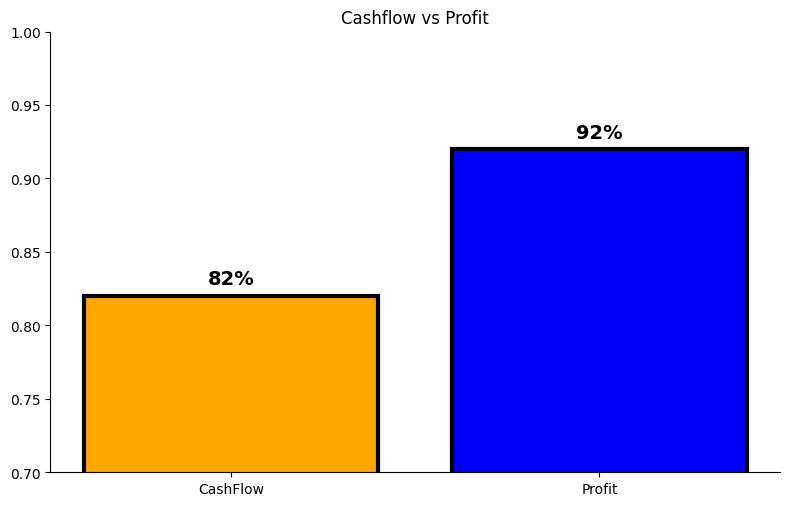

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Only show the comparison that matters
cash = 0.82
profit = 0.92

bars = ax.bar(['CashFlow', 'Profit'], [cash, profit],
              color=['orange', 'blue'], edgecolor='black', linewidth=3)
ax.set_ylim(0.7, 1.0)

# Remove clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Only essential text
for bar, val in zip(bars, [cash, profit]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
           f'{val:.0%}', ha='center', va='bottom',
           fontweight='bold', fontsize=14)

plt.tight_layout()
plt.title('Cashflow vs Profit')
plt.show()

Profitability predicts better
(92% vs 82% accuracy)

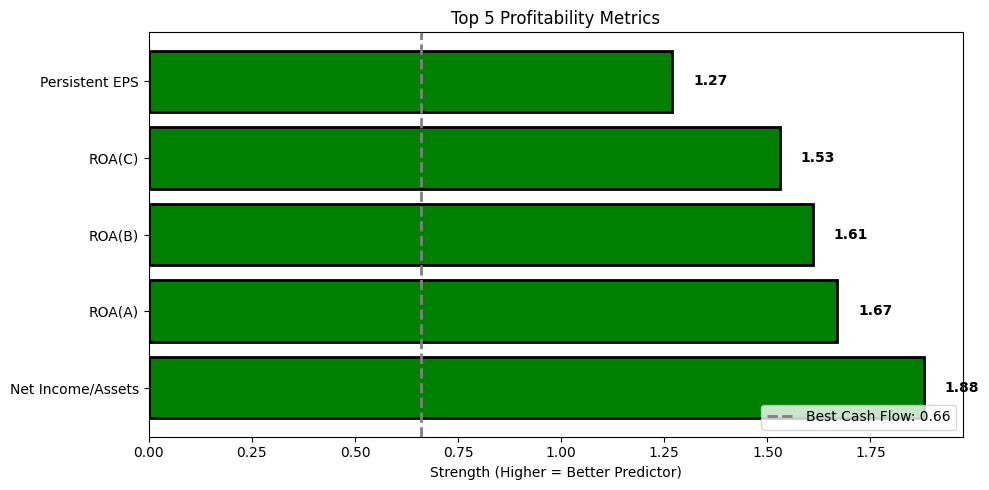

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))

# All top 5 profitability metrics from our analysis
metrics = [
    'Net Income/Assets',
    'ROA(A)',
    'ROA(B)',
    'ROA(C)',
    'Persistent EPS'
]
strengths = [1.88, 1.67, 1.61, 1.53, 1.27]

# Create horizontal bar chart (easier to read labels)
bars = ax.barh(metrics, strengths, color='green', edgecolor='black', linewidth=2)

# Add cash flow comparison line
cash_best = 0.66
ax.axvline(x=cash_best, color='gray', linestyle='--', linewidth=2,
           label=f'Best Cash Flow: {cash_best:.2f}')

# Label each bar
for i, (bar, strength) in enumerate(zip(bars, strengths)):
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2,
            f'{strength:.2f}', va='center', fontweight='bold')

ax.set_xlabel('Strength (Higher = Better Predictor)')
ax.legend(loc='lower right')
plt.title('Top 5 Profitability Metrics')
plt.tight_layout()
plt.show()

Even the 5th best profitability metric
is stronger than the best cash flow metric.